In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

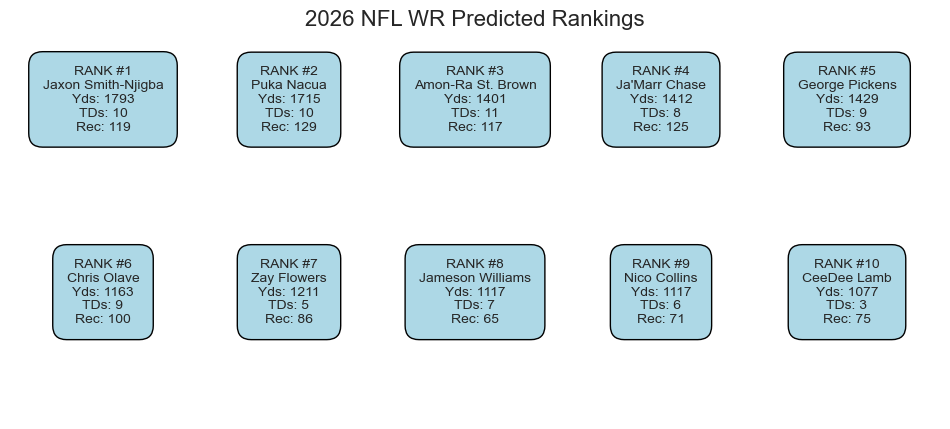

In [40]:
data = {
    'Player': [
        'Jaxon Smith-Njigba', 'Puka Nacua', 'Amon-Ra St. Brown', 'Ja\'Marr Chase', 
        'George Pickens', 'Chris Olave', 'Zay Flowers', 'Jameson Williams', 
        'Nico Collins', 'CeeDee Lamb'
    ],
    'Receiving_Yards': [1793, 1715, 1401, 1412, 1429, 1163, 1211, 1117, 1117, 1077],
    'Touchdowns': [10, 10, 11, 8, 9, 9, 5, 7, 6, 3],
    'Receptions': [119, 129, 117, 125, 93, 100, 86, 65, 71, 75],
    'Rank': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

df = pd.DataFrame(data)

X = df[['Receiving_Yards', 'Touchdowns', 'Receptions']]
y = df['Rank']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

df['Predicted_Rank'] = model.predict(X)
df = df.sort_values(by='Predicted_Rank').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')
plt.title('2026 NFL WR Predicted Rankings', fontsize=16)

for i, row in df.iterrows():
    col = i % 5
    r = 1 - (i // 5)
    
    x = col * 2
    y = r * 2
    
    box_text = f"RANK #{row['Predicted_Rank']}\n{row['Player']}\nYds: {row['Receiving_Yards']}\nTDs: {row['Touchdowns']}\nRec: {row['Receptions']}"
    ax.text(x, y, box_text, fontsize=10, bbox=dict(boxstyle="round,pad=1", facecolor="lightblue", edgecolor="black"), ha='center')

ax.set_xlim(-1, 9)
ax.set_ylim(-1, 3)
plt.show()

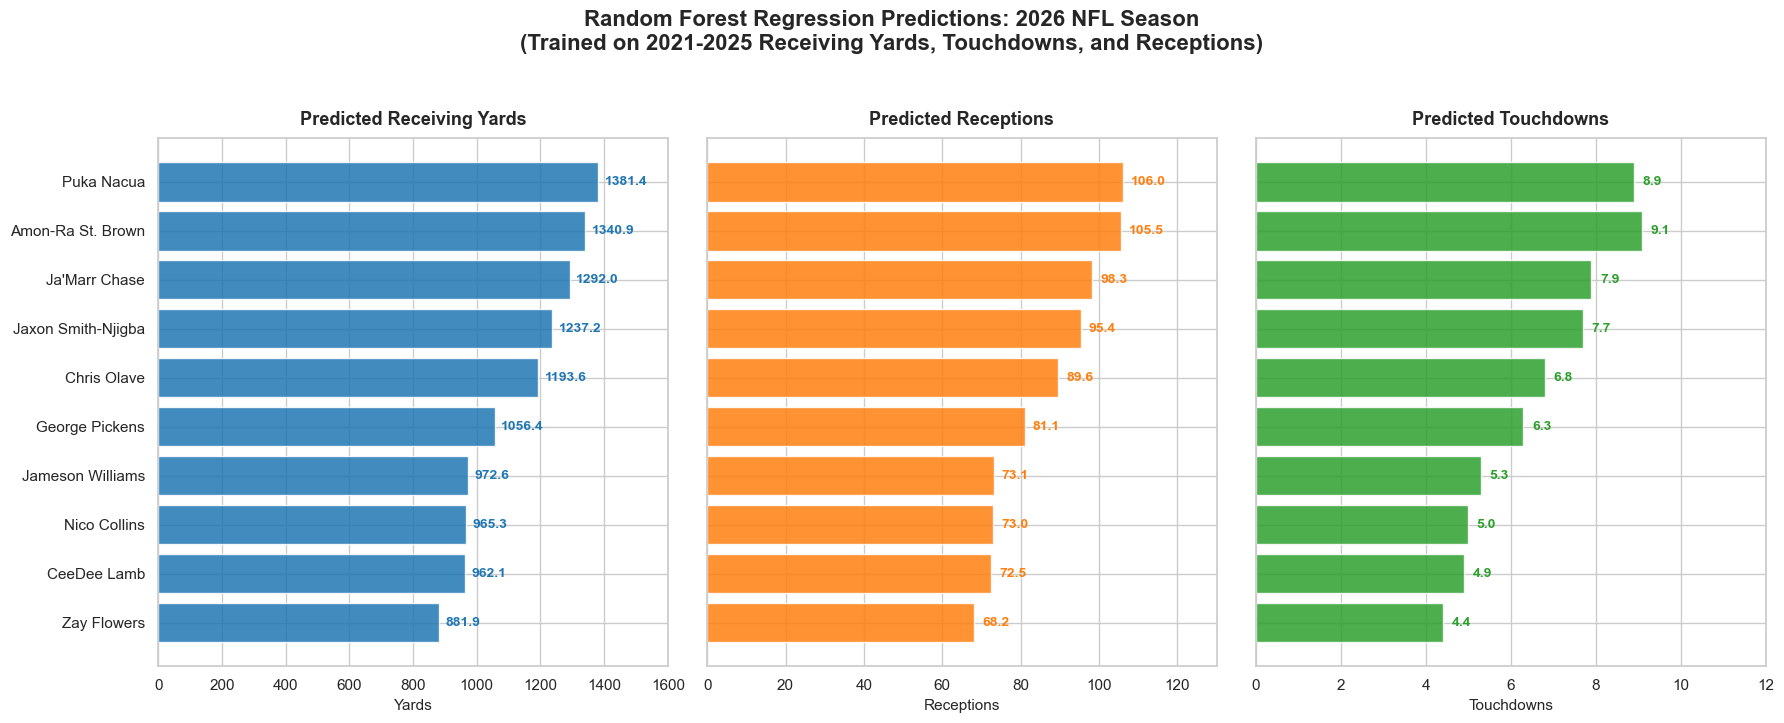

In [43]:
results_data = [
    {
        "Player": "Puka Nacua",
        "Yds_2025": 1715,
        "Pred_Yards_2026": 1381.4,
        "Pred_Receptions_2026": 106.0,
        "Pred_TDs_2026": 8.9,
    },
    {
        "Player": "Amon-Ra St. Brown",
        "Yds_2025": 1401,
        "Pred_Yards_2026": 1340.9,
        "Pred_Receptions_2026": 105.5,
        "Pred_TDs_2026": 9.1,
    },
    {
        "Player": "Ja'Marr Chase",
        "Yds_2025": 1412,
        "Pred_Yards_2026": 1292.0,
        "Pred_Receptions_2026": 98.3,
        "Pred_TDs_2026": 7.9,
    },
    {
        "Player": "Jaxon Smith-Njigba",
        "Yds_2025": 1793,
        "Pred_Yards_2026": 1237.2,
        "Pred_Receptions_2026": 95.4,
        "Pred_TDs_2026": 7.7,
    },
    {
        "Player": "Chris Olave",
        "Yds_2025": 1163,
        "Pred_Yards_2026": 1193.6,
        "Pred_Receptions_2026": 89.6,
        "Pred_TDs_2026": 6.8,
    },
    {
        "Player": "George Pickens",
        "Yds_2025": 1429,
        "Pred_Yards_2026": 1056.4,
        "Pred_Receptions_2026": 81.1,
        "Pred_TDs_2026": 6.3,
    },
    {
        "Player": "Jameson Williams",
        "Yds_2025": 1117,
        "Pred_Yards_2026": 972.6,
        "Pred_Receptions_2026": 73.1,
        "Pred_TDs_2026": 5.3,
    },
    {
        "Player": "Nico Collins",
        "Yds_2025": 1117,
        "Pred_Yards_2026": 965.3,
        "Pred_Receptions_2026": 73.0,
        "Pred_TDs_2026": 5.0,
    },
    {
        "Player": "CeeDee Lamb",
        "Yds_2025": 1077,
        "Pred_Yards_2026": 962.1,
        "Pred_Receptions_2026": 72.5,
        "Pred_TDs_2026": 4.9,
    },
    {
        "Player": "Zay Flowers",
        "Yds_2025": 1211,
        "Pred_Yards_2026": 881.9,
        "Pred_Receptions_2026": 68.2,
        "Pred_TDs_2026": 4.4,
    },
]

df = pd.DataFrame(results_data)

df = df.sort_values(by="Pred_Yards_2026", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.suptitle(
    "Random Forest Regression Predictions: 2026 NFL Season\n"
    "(Trained on 2021-2025 Receiving Yards, Touchdowns, and Receptions)",
    fontsize=16,
    fontweight="bold",
    y=1.03,
)

bars1 = axes[0].barh(
    df["Player"], df["Pred_Yards_2026"], color=color_yds, alpha=0.85
)
axes[0].set_title(
    "Predicted Receiving Yards", fontsize=13, fontweight="bold", pad=10
)
axes[0].set_xlabel("Yards", fontsize=11)
axes[0].set_xlim(0, 1600)

for bar in bars1:
    width = bar.get_width()
    axes[0].text(
        width + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        ha="left",
        va="center",
        fontweight="bold",
        color=color_yds,
        fontsize=10,
    )

bars2 = axes[1].barh(
    df["Player"], df["Pred_Receptions_2026"], color=color_rec, alpha=0.85
)
axes[1].set_title("Predicted Receptions", fontsize=13, fontweight="bold", pad=10)
axes[1].set_xlabel("Receptions", fontsize=11)
axes[1].set_xlim(0, 130)

for bar in bars2:
    width = bar.get_width()
    axes[1].text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        ha="left",
        va="center",
        fontweight="bold",
        color=color_rec,
        fontsize=10,
    )

bars3 = axes[2].barh(
    df["Player"], df["Pred_TDs_2026"], color=color_tds, alpha=0.85
)
axes[2].set_title("Predicted Touchdowns", fontsize=13, fontweight="bold", pad=10)
axes[2].set_xlabel("Touchdowns", fontsize=11)
axes[2].set_xlim(0, 12)

for bar in bars3:
    width = bar.get_width()
    axes[2].text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        ha="left",
        va="center",
        fontweight="bold",
        color=color_tds,
        fontsize=10,
    )

plt.tight_layout()
plt.show()